In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data= pd.read_csv('CLIENT 1 combined_data(2025-3-1-2026-2-28).csv')

In [3]:
data

,Channel,Uploaded Count,Created Count,Published Count,Uploaded Duration (hh:mm:ss),Created Duration (hh:mm:ss),Published Duration (hh:mm:ss)
0,A,1470,4725,71,227:24:21,410:36:38,3:02:30
1,B,1293,4251,19,297:15:05,472:02:39,0:24:19
2,C,765,2631,14,158:25:12,235:03:49,0:27:44
3,D,221,701,0,23:31:11,42:08:02,0:00:00
4,E,201,807,5,25:34:42,59:03:55,0:16:07
5,F,130,320,0,17:35:35,25:23:17,0:00:00
6,G,106,351,1,17:42:41,33:33:50,0:03:01
7,H,89,329,1,10:17:01,20:33:19,0:08:56
8,I,59,262,0,10:56:20,22:41:30,0:00:00
9,J,37,145,0,5:39:49,11:11:49,0:00:00


In [4]:
data.columns

Index(['Channel', 'Uploaded Count', 'Created Count', 'Published Count',
       'Uploaded Duration (hh:mm:ss)', 'Created Duration (hh:mm:ss)',
       'Published Duration (hh:mm:ss)'],
      dtype='object')

In [13]:
#conversion to seconds
data['Uploaded Duration (sec)']= pd.to_timedelta(data['Uploaded Duration (hh:mm:ss)']).dt.total_seconds()
data['Created Duration (sec)'] = pd.to_timedelta(data['Created Duration (hh:mm:ss)']).dt.total_seconds()
data['Published Duration (sec)'] = pd.to_timedelta(data['Published Duration (hh:mm:ss)']).dt.total_seconds()

In [14]:
#total duration
data['Total Duration(sec)']= (data['Uploaded Duration (sec)']+ data['Created Duration (sec)'] +
    data['Published Duration (sec)'])
#average duration per file
data['Avg Uploaded Duration']= data['Uploaded Duration (sec)']/data['Uploaded Count']
data['Avg Created Duration'] = data['Created Duration (sec)'] / data['Created Count']
data['Avg Published Duration'] = data['Published Duration (sec)'] / data['Published Count']

In [17]:
data

,Channel,Uploaded Count,Created Count,Published Count,Uploaded Duration (hh:mm:ss),Created Duration (hh:mm:ss),Published Duration (hh:mm:ss),Uploaded Duration (sec),Created Duration (sec),Published Duration (sec),Total Duration()sec,Avg Uploaded Duration,Avg Created Duration,Avg Published Duration,Total Duration(sec)
0,A,1470,4725,71,227:24:21,410:36:38,3:02:30,818661.0,1478198.0,10950.0,2307809.0,556.912245,312.846138,154.225352,2307809.0
1,B,1293,4251,19,297:15:05,472:02:39,0:24:19,1070105.0,1699359.0,1459.0,2770923.0,827.614076,399.755116,76.789474,2770923.0
2,C,765,2631,14,158:25:12,235:03:49,0:27:44,570312.0,846229.0,1664.0,1418205.0,745.505882,321.637780,118.857143,1418205.0
3,D,221,701,0,23:31:11,42:08:02,0:00:00,84671.0,151682.0,0.0,236353.0,383.126697,216.379458,NaN,236353.0
4,E,201,807,5,25:34:42,59:03:55,0:16:07,92082.0,212635.0,967.0,305684.0,458.119403,263.488228,193.400000,305684.0
5,F,130,320,0,17:35:35,25:23:17,0:00:00,63335.0,91397.0,0.0,154732.0,487.192308,285.615625,NaN,154732.0
6,G,106,351,1,17:42:41,33:33:50,0:03:01,63761.0,120830.0,181.0,184772.0,601.518868,344.245014,181.000000,184772.0
7,H,89,329,1,10:17:01,20:33:19,0:08:56,37021.0,73999.0,536.0,111556.0,415.966292,224.920973,536.000000,111556.0
8,I,59,262,0,10:56:20,22:41:30,0:00:00,39380.0,81690.0,0.0,121070.0,667.457627,311.793893,NaN,121070.0
9,J,37,145,0,5:39:49,11:11:49,0:00:00,20389.0,40309.0,0.0,60698.0,551.054054,277.993103,NaN,60698.0


In [18]:
# Conversion KPI
data['Upload → Publish Rate'] = data['Published Count'] / data['Uploaded Count']

In [19]:
data

,Channel,Uploaded Count,Created Count,Published Count,Uploaded Duration (hh:mm:ss),Created Duration (hh:mm:ss),Published Duration (hh:mm:ss),Uploaded Duration (sec),Created Duration (sec),Published Duration (sec),Total Duration()sec,Avg Uploaded Duration,Avg Created Duration,Avg Published Duration,Total Duration(sec),Upload → Publish Rate
0,A,1470,4725,71,227:24:21,410:36:38,3:02:30,818661.0,1478198.0,10950.0,2307809.0,556.912245,312.846138,154.225352,2307809.0,0.048299
1,B,1293,4251,19,297:15:05,472:02:39,0:24:19,1070105.0,1699359.0,1459.0,2770923.0,827.614076,399.755116,76.789474,2770923.0,0.014695
2,C,765,2631,14,158:25:12,235:03:49,0:27:44,570312.0,846229.0,1664.0,1418205.0,745.505882,321.637780,118.857143,1418205.0,0.018301
3,D,221,701,0,23:31:11,42:08:02,0:00:00,84671.0,151682.0,0.0,236353.0,383.126697,216.379458,NaN,236353.0,0.000000
4,E,201,807,5,25:34:42,59:03:55,0:16:07,92082.0,212635.0,967.0,305684.0,458.119403,263.488228,193.400000,305684.0,0.024876
5,F,130,320,0,17:35:35,25:23:17,0:00:00,63335.0,91397.0,0.0,154732.0,487.192308,285.615625,NaN,154732.0,0.000000
6,G,106,351,1,17:42:41,33:33:50,0:03:01,63761.0,120830.0,181.0,184772.0,601.518868,344.245014,181.000000,184772.0,0.009434
7,H,89,329,1,10:17:01,20:33:19,0:08:56,37021.0,73999.0,536.0,111556.0,415.966292,224.920973,536.000000,111556.0,0.011236
8,I,59,262,0,10:56:20,22:41:30,0:00:00,39380.0,81690.0,0.0,121070.0,667.457627,311.793893,NaN,121070.0,0.000000
9,J,37,145,0,5:39:49,11:11:49,0:00:00,20389.0,40309.0,0.0,60698.0,551.054054,277.993103,NaN,60698.0,0.000000


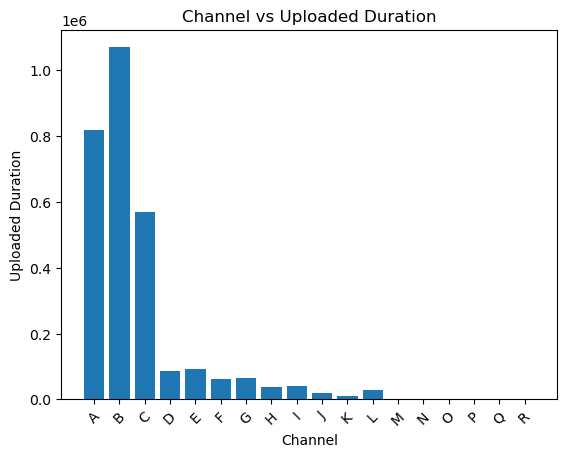

In [20]:
plt.figure()
plt.bar(data['Channel'], data['Uploaded Duration (sec)'])
plt.xticks(rotation=45)
plt.xlabel('Channel')
plt.ylabel('Uploaded Duration')
plt.title('Channel vs Uploaded Duration')
plt.show()

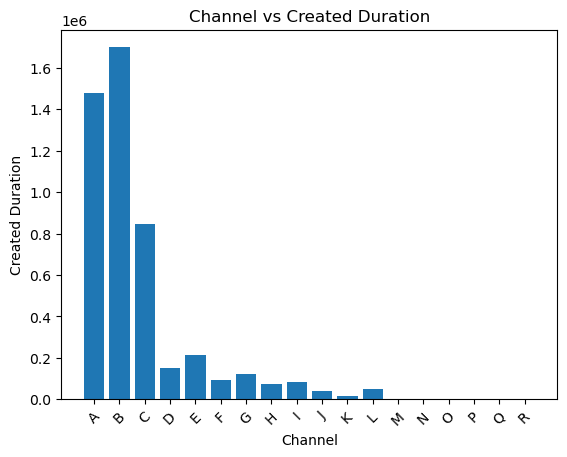

In [21]:
plt.figure()
plt.bar(data['Channel'], data['Created Duration (sec)'])
plt.xticks(rotation=45)
plt.xlabel("Channel")
plt.ylabel("Created Duration")
plt.title("Channel vs Created Duration")
plt.show()

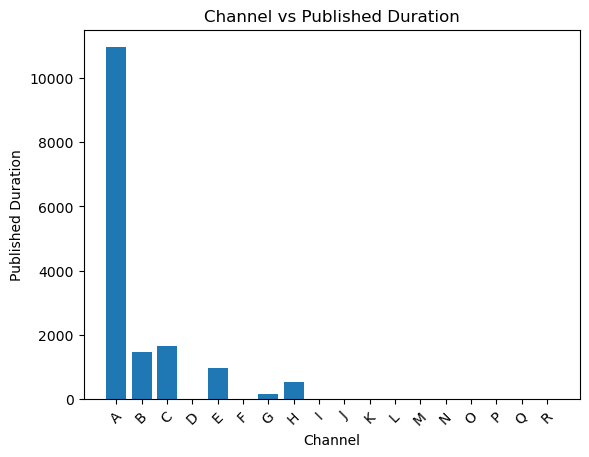

In [28]:
plt.figure()
plt.bar(data['Channel'], data['Published Duration (sec)'])
plt.xticks(rotation=45)
plt.xlabel("Channel")
plt.ylabel("Published Duration")
plt.title("Channel vs Published Duration")
plt.show()

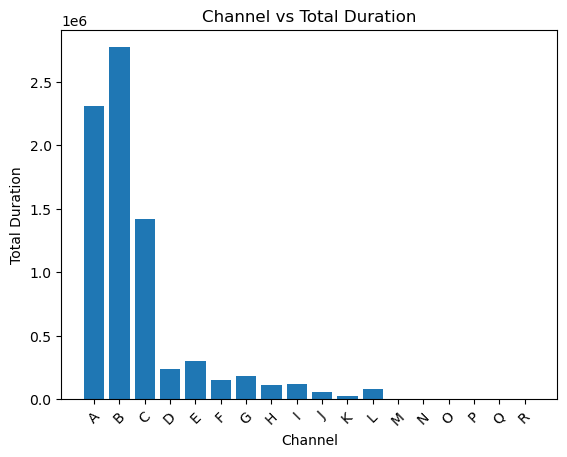

In [29]:
plt.figure()
plt.bar(data['Channel'], data['Total Duration(sec)'])
plt.xticks(rotation=45)
plt.xlabel("Channel")
plt.ylabel("Total Duration")
plt.title("Channel vs Total Duration")
plt.show()

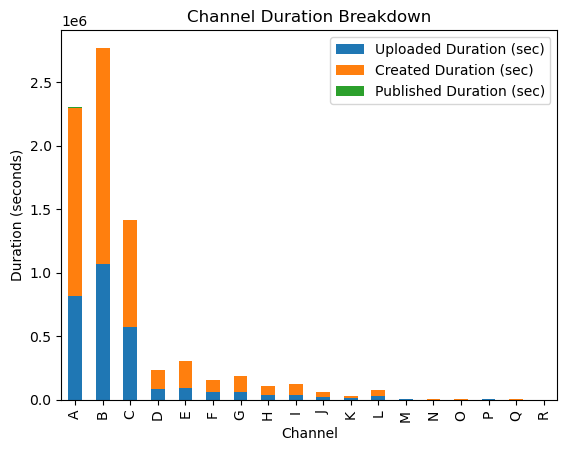

In [30]:
data.set_index('Channel')[[
    'Uploaded Duration (sec)',
    'Created Duration (sec)',
    'Published Duration (sec)'
]].plot(kind='bar', stacked=True)

plt.ylabel("Duration (seconds)")
plt.title("Channel Duration Breakdown")
plt.show()

In [1]:
import pyarrow as pa
from database import get_connection


def get_kpi01_overall_publish_rate() -> tuple[pa.Table, str]:
    """
    KPI-01: Overall Publish Rate
    SUM(Published Count) ÷ SUM(Created Count) × 100
    """
    con = get_connection()
    table = con.execute("""
        SELECT
            ROUND(
                100.0 * SUM("Published Count") / NULLIF(SUM("Created Count"), 0),
                2
            ) AS "Overall_Publish_Rate_%"
        FROM client_1_combined_data
    """).arrow()
    con.close()
    return table, "KPI 01 - Overall Publish Rate (%)"


def get_kpi02_amplification_ratio() -> tuple[pa.Table, str]:
    """
    KPI-02: Amplification Ratio
    SUM(Created Count) ÷ SUM(Uploaded Count)
    """
    con = get_connection()
    table = con.execute("""
        SELECT
            ROUND(
                1.0 * SUM("Created Count") / NULLIF(SUM("Uploaded Count"), 0),
                2
            ) AS "Amplification_Ratio"
        FROM client_1_combined_data
    """).arrow()
    con.close()
    return table, "KPI 02 - Amplification Ratio"


def get_kpi04_dropoff_volume() -> tuple[pa.Table, str]:
    """
    KPI-04: Drop-off Volume
    SUM(Created Count) − SUM(Published Count)
    """
    con = get_connection()
    table = con.execute("""
        SELECT
            SUM("Created Count") - SUM("Published Count") AS "Dropoff_Volume"
        FROM client_1_combined_data
    """).arrow()
    con.close()
    return table, "KPI 04 - Drop-off Volume"


def get_kpi05_total_content_hours() -> tuple[pa.Table, str]:
    """
    KPI-05: Total Content Hours
    SUM(Created Duration)
    """
    con = get_connection()
    table = con.execute("""
        SELECT
            ROUND(
                SUM(
                    EXTRACT(EPOCH FROM CAST("Created Duration (hh:mm:ss)" AS TIME))
                ) / 3600,
                2
            ) AS "Total_Content_Hours"
        FROM client_1_combined_data
    """).arrow()
    con.close()
    return table, "KPI 05 - Total Content Hours"


def get_kpi06_publish_rate_by_channel() -> tuple[pa.Table, str]:
    """
    KPI-06: Publish Rate by Channel
    Channel Published Count ÷ Channel Created Count × 100
    """
    con = get_connection()
    table = con.execute("""
        SELECT
            "Channel",
            "Published Count",
            "Created Count",
            ROUND(
                100.0 * "Published Count" / NULLIF("Created Count", 0),
                2
            ) AS "Publish_Rate_%"
        FROM client_1_combined_data
        ORDER BY "Publish_Rate_%" DESC NULLS LAST
    """).arrow()
    con.close()
    return table, "KPI 06 - Publish Rate by Channel (%)"


def get_kpi08_zero_publish_channels() -> tuple[pa.Table, str]:
    """
    KPI-08: Zero Publish Channel Count
    COUNT(rows WHERE Published Count = 0)
    """
    con = get_connection()
    table = con.execute("""
        SELECT
            COUNT(*) AS "Zero_Publish_Channel_Count"
        FROM client_1_combined_data
        WHERE "Published Count" = 0
    """).arrow()
    con.close()
    return table, "KPI 08 - Zero Publish Channel Count"

ModuleNotFoundError: No module named 'database'